In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

import torch 
import torch.nn as nn
from torch.optim import Adam
from torch.distributions import Categorical

import gymnasium as gym 

In [101]:
env = gym.make("LunarLander-v3",
                render_mode='rgb_array')

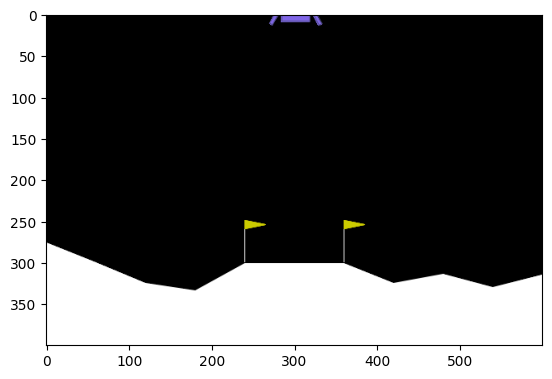

In [102]:
obs,_ = env.reset()
img = env.render()
plt.imshow(img)

In [103]:
class Actor(nn.Module):
    def __init__(self, n_states, n_actions):
        super(Actor,self).__init__()

        self.fc1 = nn.Sequential(
            nn.Linear(n_states,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,n_actions),
            nn.Softmax(dim=-1)
        )


    def forward(self, x):
        return self.fc1(x)


class Critic(nn.Module):
    def __init__(self, n_states):
        super(Critic,self).__init__()

        self.fc2 = nn.Sequential(
            nn.Linear(n_states,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )


    def forward(self, x):
        return self.fc2(x)



In [104]:
class RLAgent:
    def __init__(self,env, n_states, n_actions, n_episodes, gamma=0.99):
        self.env = env
        self.n_states = n_states
        self.n_actions = n_actions
        self.n_episodes = n_episodes

        self.gamma = gamma
        self.lr = 1e-3


        self.reward_per_10epi = []
        self.epino_forplot = []
        self.all_rewards=[]

        self.rewards = []
        self.log_prob = []

        self.states = []
        self.actions = []
        self.Rewards = []
        self.entropy = []

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.Actor = Actor(self.n_states,self.n_actions)
        self.Actor.to(self.device)
        self.Critic = Critic(self.n_states)
        self.Critic.to(self.device)
        #self.optim = Adam(
        #    list(self.Actor.parameters()) + list(self.Critic.parameters()),
        #    lr=self.lr)
        self.optim = Adam([
            {'params': self.Actor.parameters(), 'lr': 3e-4},
            {'params': self.Critic.parameters(), 'lr': 5e-3}])
              # Tried different lr to overcome plateau at around -50




    def choose_action(self,state):
        state = torch.tensor(state,dtype=torch.float32).unsqueeze(0).to(self.device)
        # PYTORCH NETWORKS ALWAYS TAKE TENSORS ONLY AS INPUT
        action_prob = self.Actor(state)

        distr = Categorical(action_prob)
        action = distr.sample()
        log_prob = distr.log_prob(action)
        self.log_prob.append(log_prob)
        entropy = distr.entropy()
        self.entropy.append(entropy)

        return action.item()


    def compute_return(self,rewards):

        G = 0
        returns = []

        for r in reversed(rewards):
            G = r + self.gamma * G
            returns.append(G)

        returns = torch.tensor(returns[::-1], dtype=torch.float32)

        #returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        #No normalize like REINFORCE kinaki G is normalized and V tries to match those small value which is bad

        return returns


    def compute_loss(self,states,rewards):

        G = self.compute_return(rewards).to(self.device) #returns a tensor which is alwasys in cpu

        states = torch.tensor(np.array(states), dtype=torch.float32).to(self.device)
        # PYTORCH NETWORKS ALWAYS TAKE TENSORS ONLY AS INPUT

        V = self.Critic(states).squeeze(-1) #o/p of nn so it is in gpu(cause we defined that in init)
        # Ouput of G is (T,) but output of V is (T,1) (from NN) so squeeze(-1) remove the last dimention



        A = G - V

        #A_norm = (A - A.mean()) / (A.std() + 1e-8)


        Actorloss = (A .detach()* (-torch.stack(self.log_prob))).mean()   # .detach() to prevent flow of grad through adv into critic twice
        # A->V-> critic weightd meaning actor loss le critic weights lai change garthiyo if there was no detach
        #we dont want actor's objective to shape critic
        Criticloss = ((A) ** 2 ).mean()
        # G is a detached tensor (no grad(since it comes from compute_return which has no NN)), so gradient only flows through V into Critic
        Entropyloss =  torch.stack(self.entropy).mean()      # Before stack — list of tensors
                                                             #[tensor(1.38), tensor(1.25), tensor(1.41)]
                                                             # After stack — single tensor
                                                             #tensor([1.38, 1.25, 1.41])
        loss = Actorloss + 0.5 * Criticloss - 0.01 * Entropyloss # - sign means we want to max entropy)

        self.optim.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(self.Actor.parameters()) + list(self.Critic.parameters()),
            max_norm = 0.5
        )
        self.optim.step()                                                
        del self.log_prob[:]
        del self.entropy[:]



    def train(self):
        
        for episode in range(self.n_episodes):
            state,_ = self.env.reset()
            total_reward = 0
            done = False
            self.states = []
            self.actions = []
            self.rewards = []
            self.log_prob = []
            self.entropy = []
            


            while not done:
                action = self.choose_action(state)
                next_state, reward, term, trunc, _ = self.env.step(action)
                done = term or trunc

                self.states.append(state)
                self.rewards.append(reward)
                self.actions.append(action)


                total_reward += reward

                state = next_state
        
            self.compute_loss(self.states,self.rewards)

            self.all_rewards.append(total_reward)
            
            if episode % 10 == 0:
                self.epino_forplot.append(episode)
                avg_reward = np.mean(self.all_rewards[-10:])
                self.reward_per_10epi.append(avg_reward)
            
            avg = np.mean(self.all_rewards[-10:]) if self.all_rewards else 0
            print(f"Episode {episode} | Average_Reward: {avg:.2f} | Current_Reward: {total_reward:.2f}")

                                    
    def plot(self):
        moving_avg = np.convolve(self.all_rewards, np.ones(100)/100, mode='same')
        fig, ax = plt.subplots(figsize = (8,6))
        ax.plot(self.epino_forplot,self.reward_per_10epi,color='blue',label="Reward Per 10 Episodes")
        ax.plot(moving_avg, color='red', label="Moving Average")

        ax.set_xlabel("Episode")
        ax.set_ylabel("Reward")
        ax.set_title("A2C Training Progress")
        ax.legend(loc="upper left")
        plt.show()






        


In [106]:
Agent = RLAgent(env, 8, 4, 6000)

In [107]:
Agent.train()

Episode 0 | Average_Reward: -87.49 | Current_Reward: -87.49
Episode 1 | Average_Reward: -101.24 | Current_Reward: -114.99
Episode 2 | Average_Reward: -149.35 | Current_Reward: -245.57
Episode 3 | Average_Reward: -174.23 | Current_Reward: -248.89
Episode 4 | Average_Reward: -162.77 | Current_Reward: -116.90
Episode 5 | Average_Reward: -225.82 | Current_Reward: -541.10
Episode 6 | Average_Reward: -203.83 | Current_Reward: -71.87
Episode 7 | Average_Reward: -191.41 | Current_Reward: -104.51
Episode 8 | Average_Reward: -195.86 | Current_Reward: -231.44
Episode 9 | Average_Reward: -176.22 | Current_Reward: 0.60
Episode 10 | Average_Reward: -170.46 | Current_Reward: -29.96
Episode 11 | Average_Reward: -175.34 | Current_Reward: -163.78
Episode 12 | Average_Reward: -159.12 | Current_Reward: -83.39
Episode 13 | Average_Reward: -181.20 | Current_Reward: -469.62
Episode 14 | Average_Reward: -183.30 | Current_Reward: -137.96
Episode 15 | Average_Reward: -136.90 | Current_Reward: -77.04
Episode 16 

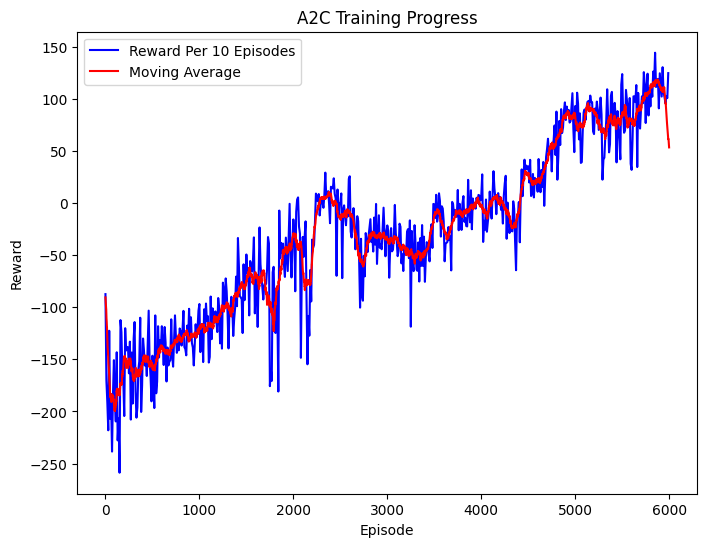

In [108]:
Agent.plot()

In [109]:
torch.save({
    'actor': Agent.Actor.state_dict(),
    'critic': Agent.Critic.state_dict(),
    'optimizer': Agent.optim.state_dict(),
}, 'a2c_save.pth')

In [110]:
checkpoint = torch.load('a2c_save.pth')
Agent.Actor.load_state_dict(checkpoint['actor'])
Agent.Critic.load_state_dict(checkpoint['critic'])
Agent.optim.load_state_dict(checkpoint['optimizer'])

Agent.Actor.eval()
Agent.Critic.eval()


Critic(
  (fc2): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [112]:
env = gym.make("LunarLander-v3",render_mode='human')

for i in range(3):
    done = False
    total_reward = 0
    state,_ = env.reset()

    while not done:

        action = Agent.choose_action(state)
        next_state, reward, term, trunc, _ = env.step(action)
        done = term or trunc
        state = next_state
        total_reward += reward

    print(f'Total Reward This Episode: {total_reward}')
env.close()


Total Reward This Episode: 129.392970448582
Total Reward This Episode: 115.84595684415562
Total Reward This Episode: 118.84005576885127
